# Projeto Final


## Descrição do projeto

A finalidade do presente projeto é a criação de um modelo de predição do diagnóstico de Hipertiroidismo. A seguir serão apresentadas cada uma das quatro etapas desse desenvolvimento: exploração e preparação dos dados, análise exploratória, seleção e avaliação de modelos e comunicação dos resultado.

Na primeira etapa, exploração e preparação dos dados, estão descritos as correções aplicadas à base de dados. Por vezes, essas correções podem influenciar no resultado final, sendo importante conhecermos o tratamento de dados para compreender o resultado final. A seguir, na etapa de análise exploratória, uma análise visual e estatística dos dados será explorada. Na terceira etapa, serão discutidos as opções de modelo que melhor se adequam aos objetivos do projeto, os modelos serão criados e avaliados. Por fim, o desempenho dos modelos e demais resultados serão apresentados.




## Exploração e Preparação dos dados

trocar dados categoricos f e t por binários
dados faltantes com ?
coluna alvo: binaryclass
P: caso positivo de tiroidismo
N: tiroidismo não identificado

In [ ]:
import pandas as pd
import re

import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import recall_score, accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score, precision_score

In [2]:
data = pd.read_csv('dados.csv')

In [3]:
print(data.head())

  age sex on thyroxine query on thyroxine on antithyroid medication sick  \
0  41   F            f                  f                         f    f   
1  23   F            f                  f                         f    f   
2  46   M            f                  f                         f    f   
3  70   F            t                  f                         f    f   
4  70   F            f                  f                         f    f   

  pregnant thyroid surgery I131 treatment query hypothyroid  ... TT4 measured  \
0        f               f              f                 f  ...            t   
1        f               f              f                 f  ...            t   
2        f               f              f                 f  ...            t   
3        f               f              f                 f  ...            t   
4        f               f              f                 f  ...            t   

   TT4 T4U measured   T4U FTI measured  FTI TBG measured

já de cara vemos que alguns dados estão marcados com "?", que deve ser ausente.
vo investigar mais cuidadosamente a presença de nulos e de "?".
Esses valores não são reconhcidos como nulos, e não nulos na base.
além disso, todos os valores são objetos, como mostram os resultados a seguir

In [4]:
temp = data.isnull().sum()
for i,n in enumerate(temp):
     if n > 0: print(f"{i}: {n}")

In [5]:
tipo_var=['number', 'int64', 'float', 'bool', 'object', 'string']
print(f'Número de variáveis do tipo')
for i in tipo_var:
    print(f'{i}: {data.dtypes[data.dtypes == i].count()}')


Número de variáveis do tipo
number: 0
int64: 0
float: 0
bool: 0
object: 30
string: 0


Os resultados acima mostram que todas as variáveis são objetos, quando sabemos que algumas deveriam ser números. Inicialmente vamos identificar qual deveria ser o tipo de cada variável. Depois todas as variáveis serão transformadas em numéricas, com os devidos métodos aplicados a cada uma. Só depois os valores ausentes serão corrigidos. 

In [6]:
column_number = []
column_letters = []
column_others = []

for i in data.columns:
    amostra = data[i].iloc[0]

    if re.match(r'^\d+$', str(amostra)):
        column_number.append(i)
    
    elif re.match(r'^[a-zA-Z]+$', str(amostra)):
        column_letters.append(i)

    else:
        column_others.append(i)

print("Colunas numéricas:", column_number)
print("Colunas com letras:", column_letters)
print("Outras colunas:", column_others)


Colunas numéricas: ['age', 'TT4', 'FTI']
Colunas com letras: ['sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured', 'referral source', 'binaryClass']
Outras colunas: ['TSH', 'T3', 'T4U', 'TBG']


['TSH', 'T3', 'T4U', 'TBG'] foram classificados como outros, então qual será que deveria ser seu valor?


In [7]:
for i in column_others:
    print(f'Valores únicos em {i}: {len(data[i].unique())}')
    print(f'{data[i].head()}')

Valores únicos em TSH: 288
0     1.3
1     4.1
2    0.98
3    0.16
4    0.72
Name: TSH, dtype: object
Valores únicos em T3: 70
0    2.5
1      2
2      ?
3    1.9
4    1.2
Name: T3, dtype: object
Valores únicos em T4U: 147
0    1.14
1       ?
2    0.91
3       ?
4    0.87
Name: T4U, dtype: object
Valores únicos em TBG: 1
0    ?
1    ?
2    ?
3    ?
4    ?
Name: TBG, dtype: object


Pelo resultado, fica claro que 'TSH', 'T3', 'T4U' são numéricos, e que TBG é uma coluna vazia. A coluna TBG será desprezada, pois não acrescenta nenhuma informação, e as três últimas serão anexadas ao grupo de variáveis numéricas. 

In [8]:
column_number.append('TSH')
column_number.append('T3')
column_number.append('T4U')
data.drop('TBG', axis = 1, inplace=True)

transformar todos as variaveis da lista column_number em numéricos. a função tu_nomeric, com o parametro coerce, transformas todos os valores nao numericos, como '?', em nulos.

In [9]:
for i in column_number:
    data[i] = pd.to_numeric(data[i], errors='coerce')
    print(f'\n{i} -> Tipo: {data[i].dtype}, nulos: {data[i].isnull().sum()}, %total: {data[i].isnull().sum()/len(data)*100:.2f}%')


age -> Tipo: float64, nulos: 1, %total: 0.03%

TT4 -> Tipo: float64, nulos: 231, %total: 6.12%

FTI -> Tipo: float64, nulos: 385, %total: 10.21%

TSH -> Tipo: float64, nulos: 369, %total: 9.78%

T3 -> Tipo: float64, nulos: 769, %total: 20.39%

T4U -> Tipo: float64, nulos: 387, %total: 10.26%


COm essa informação em mãos, podemos avaliar o comportamento das variáveis numéricas e escolher qual estratégia será usada para o tratamento dos valores nulos. Após essa etapa, voltaremos etapa de transformação em valores lógicos, numéricos, das variavéis categóricas.

In [10]:
subplotsTitles = []
for i in column_number:
     subplotsTitles.append(f'Histograma de {i}')
     subplotsTitles.append(f'Boxplot de {i}')


fig = make_subplots(rows=len(column_number), cols=2, subplot_titles=subplotsTitles)
row = 1
# col = 1

for i in column_number:
    histogram = px.histogram(data, x=i, nbins=80, histnorm='percent')
    box = px.box(data, y=i)
    fig.add_trace(
        histogram.data[0],
        row=row, col=1,
    )

    fig.add_trace(
        box.data[0],
        row=row, col=2
    )
    row += 1
fig.update_layout(title_text='Histogramas das Colunas Numéricas', showlegend=False, height=3000, width=1300 )
fig.show()



Da análise dos histogramas e dos dados, percebe-se que todos possuem médias muito bem marcadas, com uma frequêncial frequência consideravelmente maior do que as dos de mais valores. Esse comportamento torna seguro a substituição dos valores nulos pela média.
Antes de aplciar a substituição, é preciso tratar também os outliers.

Foram identificados como outlaires
- valor máximo de age
- doi maiores valores de tt4, valores acima de 350
- fti valore acima de 300
- tsh valor acima de 300
- valor t3 acima de 8
- valores negativos de t4u

a riscos quando se exclui valores altos, pois podem ser valores razoáveis que descrevem exatamente a população com índices mais graves e razos.
infelizmente, não tenho certeza de quais são as unidades das medidas, então não é possível comprar com valores conhecidos.

as pesquisas indicaram algumas faixas de valores que poderiam ser usadas de base para determinar quais valores são outliers. mpara algumas variáveis os valores estão muito distantes, então optei por aplicar apenas a análise dos dados sem a comparação com estudos anteriores.

fiz uma mistura, me basiei um pouco nas ref, um pouco na análise do box plot, outro pouco no 75% + 2*std, e no iqr



**TSH: Hormônio estimulante da tireoide (thyroid-stimulating hormone)**
- Hipertiroidismo: abaixo de 0,3 mlU/l; 0 to 0.4 mU/L
- Normal: entre 0,3 e 0,4 mlU/l; 0.4 to 4 mU/L
- Hipotiroidismo: acima de 0,4 mlU/l. 4–10 mU/L	10 mU/L
- 1 semana de vida: valores 15 mUI/L = normal


**T3: Triiodotironina (geralmente T3 total quando não especificado “livre”)**
-  Os valores normais de T3 costumam variar entre 80 e 200 ng/dL,
​

**TT4: T4 total, ou tiroxina total. e T4U (T4 uptake)**
- Teste de captação de T4 pelas proteínas ligadoras, usado para corrigir alterações de proteínas séricas.
- Children up to 5 years old: 0.8 – 2.8 nanograms per deciliter (ng/dL).
- Children 6 to 15 years old: 0.8 – 2.1 ng/dL.
- Male adolescents 16 to 17 years old: 0.8 – 2.8 ng/dL.
- Female adolescents 16 to 17 years old: 0.8 – 1.5 ng/dL.
- Adults over 18 years old: 0.9 – 1.7 ng/dL.
- Free T4 test results are usually accurate. However, certain factors may interfere with the results, including:
    - Certain medications or supplements.
    - Pregnancy.
    - Severe illness or malnourishment.
​

**FTI (Free Thyroxine Index ou Índice de Tiroxina Livre)**
- Índice calculado (T4 total × fator derivado do T4U) para estimar a tiroxina livre antes da ampla disponibilidade do T4 livre direto.
- Em muitos locais, os intervalos considerados normais ficam em torno de:
- 0,7 a 1,8 ng/dL para adultos.

**Referências**
- https://my.clevelandclinic.org/health/diagnostics/24235-thyroxine-t4-test
- https://www.rededorsaoluiz.com.br/exames-e-procedimentos/analises-clinicas/indice-tiroxina-livre
- https://www.saudebemestar.pt/pt/exame/analises-clinicas/tsh/
- https://sergiofranco.com.br/saude/exame-de-tireoide-tsh
- https://fleminglaboratorio.com/glossario/exames-tireoide-valores-normais/

In [11]:
# Resumo estatístico dos dados
print(data[column_number].describe())

               age          TT4          FTI          TSH           T3  \
count  3771.000000  3541.000000  3387.000000  3403.000000  3003.000000   
mean     51.735879   108.319345   110.469649     5.086766     2.013500   
std      20.084958    35.604248    33.089698    24.521470     0.827434   
min       1.000000     2.000000     2.000000     0.005000     0.050000   
25%      36.000000    88.000000    93.000000     0.500000     1.600000   
50%      54.000000   103.000000   107.000000     1.400000     2.000000   
75%      67.000000   124.000000   124.000000     2.700000     2.400000   
max     455.000000   430.000000   395.000000   530.000000    10.600000   

               T4U  
count  3385.000000  
mean      0.995000  
std       0.195457  
min       0.250000  
25%       0.880000  
50%       0.980000  
75%       1.080000  
max       2.320000  


In [12]:
diqr = pd.DataFrame(columns=['min', 'max', 'upper_bound'])
for i in column_number:
    q1 = data[i].quantile(0.25)
    q3 = data[i].quantile(0.75)
    iqr = q3 - q1
    # lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    diqr.loc[i] = [data[i].min(), data[i].max(), upper_bound]

print(diqr)

       min     max  upper_bound
age  1.000  455.00       113.50
TT4  2.000  430.00       178.00
FTI  2.000  395.00       170.50
TSH  0.005  530.00         6.00
T3   0.050   10.60         3.60
T4U  0.250    2.32         1.38


voltanto, os valores que serão EXCLUÍDOS são:
Foram identificados como outlaires
- valor máximo de age
- doi maiores valores de tt4, valores acima de 350
- fti valore acima de 300
- tsh valor acima de 300
- valor t3 acima de 8
- nenhum valor em t4u

In [13]:
data = data[data['age'] < 100]
data = data[data['TT4'] < 200]
data = data[data['FTI'] < 200]
data = data[data['TSH'] < 30]
data = data[data['T3'] < 8]
data = data[data['T4U'] < 8]
print(data.shape)

(2597, 29)


In [14]:
for i in column_number:
    data[i] = pd.to_numeric(data[i], errors='coerce')
    print(f'\n{i} -> Nulos: {data[i].isnull().sum()}, %total: {data[i].isnull().sum()/len(data)*100:.2f}%')


age -> Nulos: 0, %total: 0.00%

TT4 -> Nulos: 0, %total: 0.00%

FTI -> Nulos: 0, %total: 0.00%

TSH -> Nulos: 0, %total: 0.00%

T3 -> Nulos: 0, %total: 0.00%

T4U -> Nulos: 0, %total: 0.00%


outra estratégia para o tratamento de dados poderia ser excluir os campos que não tem todas as medidas, em que  TSH measured, T3 measured, TT4 measured: , TT4 measured, FTI measured e TBG measured  são falsos. A estratégia utilizado buscou exercitar a análise numérica e comportamental das variáveis. Mas a outra estratégia seria mais ágil .

Feito então, substitui nulos dos numéricos, corrigi outlieres, agora é a vez de olharmos novamente para as variaveis categóricas

verificou-se que não há erros de digitação nem variações de escrita para os mesmos valores.
a classe sex possui '?', será subsituído por "NI", de não informado, not informed.
a classe sex referral source será transformada com uma adaptação da técnica  Label Encoder, em que Atribui um número único a cada valor único na sua coluna categórica, cata categoria vira um número inteiro,  memória, pois usa apenas uma coluna para representar a variável.
as de mais com o valor f será transformado em 0 e o valor t em 1., p =1 n =0,

 m=1, f =0, ?=2

as categorias TSH measured, T3 measured, TT4 measured: , TT4 measured, FTI measured e TBG measured serão eliminadas por que contém apenas um valor, t, que indica que a medida foi feita.

In [15]:
for i in column_letters:
    print(f'{i}: {data[i].unique()}')

sex: ['F' 'M' '?']
on thyroxine: ['f' 't']
query on thyroxine: ['f' 't']
on antithyroid medication: ['f' 't']
sick: ['f' 't']
pregnant: ['f' 't']
thyroid surgery: ['f' 't']
I131 treatment: ['f' 't']
query hypothyroid: ['f' 't']
query hyperthyroid: ['f' 't']
lithium: ['f' 't']
goitre: ['f' 't']
tumor: ['f' 't']
hypopituitary: ['f' 't']
psych: ['f' 't']
TSH measured: ['t']
T3 measured: ['t']
TT4 measured: ['t']
T4U measured: ['t']
FTI measured: ['t']
TBG measured: ['f']
referral source: ['SVHC' 'SVI' 'other' 'STMW' 'SVHD']
binaryClass: ['P' 'N']


In [16]:
data = data.drop(['TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured'], axis = 1)
column_letters.remove('TSH measured') 
column_letters.remove('T3 measured')
column_letters.remove('TT4 measured')
column_letters.remove('T4U measured')
column_letters.remove('FTI measured')
column_letters.remove('TBG measured')

In [17]:
for i in column_letters:
        data[i] = data[i].replace('t', 1)
        data[i] = data[i].replace('f', 0)

        data[i] = data[i].replace('M', 1)
        data[i] = data[i].replace('F', 0)
        data[i] = data[i].replace('?', 2)

        data[i] = data[i].replace('P', 1)
        data[i] = data[i].replace('N', 0)

        data[i] = data[i].replace('other', 0)
        data[i] = data[i].replace('STMW', 1)
        data[i] = data[i].replace('SVHC', 2)
        data[i] = data[i].replace('SVHD', 3)
        data[i] = data[i].replace('SVI', 4)

for i in column_letters:
    print(f'{i}: {data[i].unique()}')

sex: [0 1 2]
on thyroxine: [0 1]
query on thyroxine: [0 1]
on antithyroid medication: [0 1]
sick: [0 1]
pregnant: [0 1]
thyroid surgery: [0 1]
I131 treatment: [0 1]
query hypothyroid: [0 1]
query hyperthyroid: [0 1]
lithium: [0 1]
goitre: [0 1]
tumor: [0 1]
hypopituitary: [0 1]
psych: [0 1]
referral source: [2 4 0 1 3]
binaryClass: [1 0]


/tmp/ipykernel_3549/1792849895.py:7: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_3549/1792849895.py:3: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_3549/1792849895.py:16: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_3549/1792849895.py:10: FutureWarning:



## Correlação das variáveis

seguem os valores de correlçao para a variável alvo, no mapa de cor eles estão apenas os módulos e ordenados. vemos que as variaveis explicativas que mais influenciam são a gravidez (pregnant), referral source, t3, t4u.


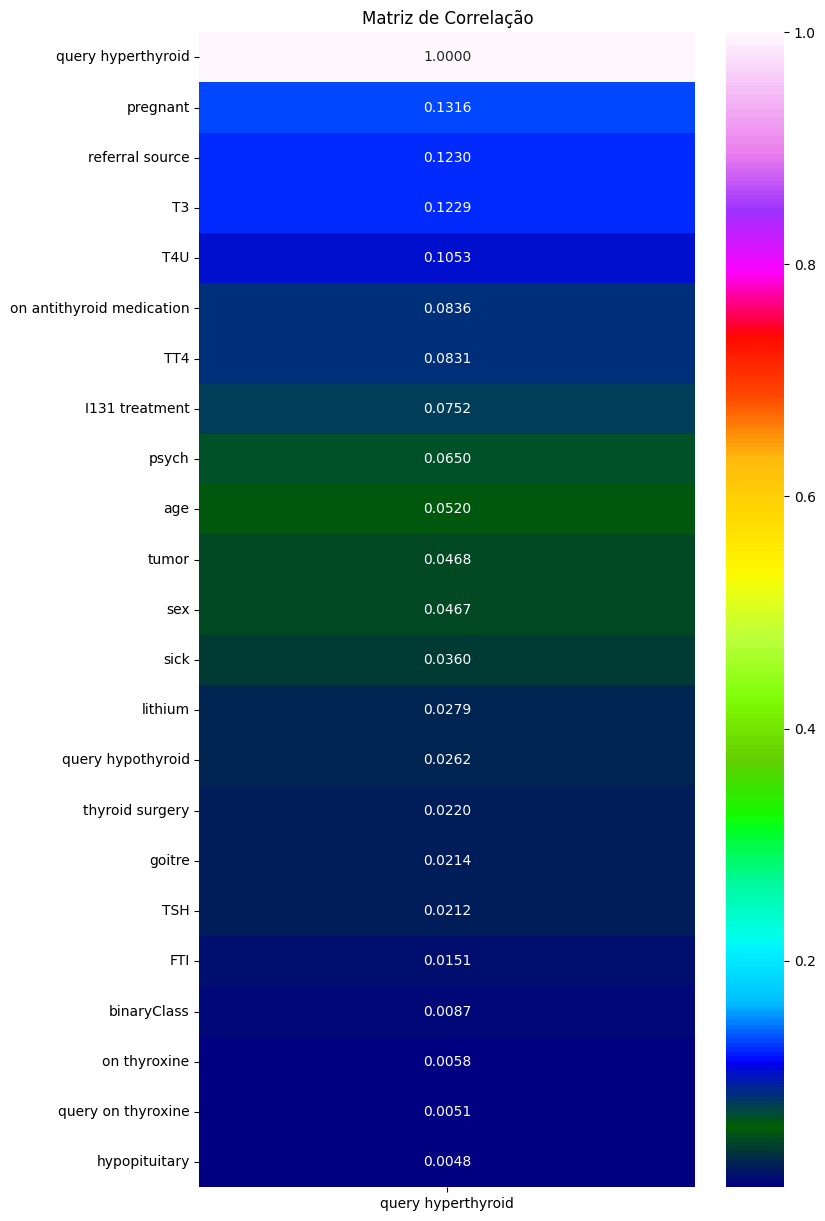

In [18]:
correlation_matrix = data.select_dtypes(include=['number']).corr()

correlation_matrix_filter = correlation_matrix[correlation_matrix['query hyperthyroid']>=0.2]

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(8, 15))
sns.heatmap(abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid',ascending=False), annot=True, cmap='gist_ncar', fmt=".4f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

## Separar variáveis explicativas (features) e alvo (targer)

In [19]:
x = data.drop('query hyperthyroid', axis = 1)
y = data['query hyperthyroid']
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

### Base 2: PCA


#### Análise de Componentes Principais (PCA)

As componentes principais no PCA são combinações lineares das variáveis originais que formam bases ortoganais que descrevem a maior parte das variáveis explicativas. Tem como objetivo diminuir a complexidade dos dados.

O gráfico de variância explicada acumulada por componente, a seguir, indica quanto do comportamento da base de dados pode ser explicada a cada novo componente que se adiciona.

In [20]:
from sklearn.decomposition import PCA

AttributeError: 'Index' object has no attribute 'index'

In [45]:
pca = PCA(n_components=  22 )
pca.fit(x)

,n_components,22
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [46]:
# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_
# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

# Plotando a variância explicada acumulada
df_pca = pd.DataFrame({
    'n_components': range(1, len(cumulative_variance) + 1),
    'cumulative_variance': cumulative_variance})

fig = px.line(df_pca, x='n_components', y='cumulative_variance',
    markers=True, title='Variância Explicada Acumulada por Componente',
    labels={'n_components': 'Número de Componentes', 'cumulative_variance': 'Variância Explicada Acumulada'})
fig.update_layout(xaxis=dict(dtick=1, tickmode='linear', range=[1, len(cumulative_variance)]),
                  yaxis=dict(range=[0, 1]))
fig.show()



No gráfico acima, com 3 componentes é possível explicar  a totalidade dos dados
Cada componente indicado no eixo x é uma combinação linear das categorias da base. Assim, ao escolher descrever a base com 3 variáveis não estamos excluindo as demais variáveis. O que ocorre e que cada uma dessas componentes tem coeficientes que dão um peso de imporância para cada variável. 
Cada coeficiente desses múltiplica uma categoria de análise diferente da nossa base. Para aplicar o PCA não é necessário saber a relação entre esses coeficientes e suas categorias, mas é interessante analisar isso para fins de estudo.
Abaixo foi organizado um dataframe relacionando cada coeficiente a suas respectivas categorias. Repare a distribuição dos coeficientes para cada categoria da componente 1.

a seguir o módulo de peso

In [47]:
# Organiza os componentes principais em um DataFrame
componentes = pd.DataFrame(pca.components_, columns=x.columns)
print(abs(componentes.loc[0]).sort_values(ascending=False))

TT4                          0.756842
FTI                          0.652749
TSH                          0.032247
T3                           0.006246
referral source              0.004132
on thyroxine                 0.001861
age                          0.001749
binaryClass                  0.001630
sex                          0.001363
T4U                          0.001183
sick                         0.000261
psych                        0.000218
pregnant                     0.000186
goitre                       0.000100
on antithyroid medication    0.000098
tumor                        0.000086
query hypothyroid            0.000077
lithium                      0.000049
hypopituitary                0.000026
I131 treatment               0.000020
query on thyroxine           0.000013
thyroid surgery              0.000012
Name: 0, dtype: float64


curiosamente,com excessão do T3, as variáveis que estão mais correlacionadas com a variável alvo, pregnant), referral source, t4u., não são as com maior peso. isso pode correr em função da confusão entre correlacionadas e codependentes. O fato de ser correlacionadas não significa que possuem relação de causa e efeito. Por exewmplo, a variacel referral source indica a fonte dos dados, e não indica nenhuma característica direta do paciente 

pdoe-se agora escolher quantas componentes serão escolhidas. são 3

In [48]:
pca_3 = PCA(n_components=3)
x_pca = pca_3.fit_transform(x)

## Cross validation

Paralelamente, devido a complexidade dos dados, serão aplicados a eles o cross validation
importante destacar que serão testadsa duas bases. a base alterada manualmente nos processos anteriores, nomeada como x_trains_balanced, e a base com cross validation, que cria um número igual a folds de bases de treino e teste


cross validation
Quando usar?
Modelos complexos ou pequenos conjuntos de dados:
Quando estamos trabalhando com modelos mais
complexos ou quando temos uma quantidade limitada de
dados, é crucial avaliar o modelo de maneira mais robusta
Comparação de modelos: Quando queremos comparar
diferentes modelos ou diferentes configurações do
mesmo modelo, o cross validation oferece uma
avaliação mais precisa. 
]Porque usar:
Avaliação mais confiável: Ao invés de depender de
uma única divisão entre treino e teste, o cross
validation usa múltiplas divisões, o que resulta em uma
avaliação mais confiável e menos sujeita a variações.
Uso eficiente dos dados: Com o cross validation, todos os
dados disponíveis são utilizados tanto para treino quanto
para teste, em diferentes iterações. Isso é especialmente
importante quando temos uma quantidade limitada de
dados.

In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
folds = 7   
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=5)


## Seleção dos modelos

problema de classificação multiclasse 
minimizar os falsos negativos para garantir que nenhum caso passe desbercebido
análise visual

Falsos positivos e negativos

Termos usados para descrever erros em modelos de classificação. Falsos positivos ocorrem quando o modelo prevê incorretamente a presença de uma condição, enquanto falsos negativos ocorrem quando o modelo não detecta uma condição que está presente.

A construção de um modelo de predição eficaz para pacientes com hipertiroidismo é uma tarefa complexa, especialmente quando se busca minimizar os falsos negativos. Neste contexto, a escolha do algoritmo é fundamental, pois a capacidade do modelo em identificar corretamente casos positivos (pacientes com hipertiroidismo) impacta diretamente na eficácia do diagnóstico e no acompanhamento dos pacientes.

Minimizar os falsos negativos é crucial em problemas de saúde, pois significa garantir que os casos reais de hipertiroidismo não sejam perdidos durante a predição. Um falso negativo em um diagnóstico de hipertiroidismo pode levar a complicações sérias, comprometendo a saúde do paciente. Portanto, a avaliação dos modelos deve incluir não apenas a precisão, mas também métricas que considerem a sensibilidade e o recall.


Modelos de Classificação Ordenados

A seguir, apresentamos uma lista dos principais métodos trabalhados no curso e sua aplicação como algoritmos de classificação.

| Modelo                | Justificativa                                                                                     |
|-----------------------|--------------------------------------------------------------------------------------------------|
| **XGBoost**           | O XGBoost é um algoritmo de aprendizado de máquina que implementa gradiente boosting, conhecido por sua alta precisão em tarefas de classificação. Ele é especialmente eficiente em lidar com dados desbalanceados e tem opções que minimizam falsos negativos.        |
| **Random Forest**     | Este algoritmo utiliza várias árvores de decisão para realizar classificações. Por ser um modelo ensemble, o Random Forest é robusto contra o sobreajuste (*overfitting*) e oferece boa generalização, ajudando a melhorar a identificação de casos positivos. |
| **SVM** | Ideal para problemas de alta dimensionalidade, o SVM pode lidar com binários e multiclasse de forma eficaz, utilizando diferentes kernels para classificar os dados, o que pode ser benéfico na minimização de falsos negativos. |
| **Árvore de Decisão** | As árvores de decisão são intuitivas e fáceis de interpretar. Elas podem capturar relações não-lineares nos dados, embora sejam propensas a sobreajuste. Um cuidado extra na configuração pode ajudar a melhorar o desempenho.     |
| **Regressão Logística** | Um modelo estatístico utilizado principalmente para problemas binários, mas pode ser estendido para casos multiclasse. A regressão logística é benéfica por fornecer probabilidades preditivas, permitindo interpretação clara dos resultados. |
| **Regressão Polinomial** | Embora usualmente aplicada para regressão, a técnica pode ser adaptada para problemas de classificação. Contudo, a complexidade interpretativa e o risco de sobreajuste requerem atenção cuidadosa. |
| **Naive Bayes**       | Este algoritmo é eficiente e rápido, adequado para classificações, especialmente em conjuntos de dados grandes. Embora presuma a independência entre as características, pode ainda fornecer boas estimativas em casos práticos. |
| **K-Means**           | Trata-se de um algoritmo de agrupamento, não especificamente de classificação. Pode ser útil na exploração inicial de dados, mas não deve ser utilizado como modelo de predição direta. |
| **Regressão Linear**  | Este modelo não é apropriado para problemas de classificação, visto que é mais focado em previsões numéricas. Usá-lo para classificação pode resultar em interpretações errôneas. |


A partir desse resumo, fica fácil entender por que os modelos escolhidos foram o **Xboost**, **Random Forest** e **SVM**.
A fim de comparação, todos os modelos serão treinados com os **dados balanceados e normalizados** e com os **dados crossvalidation**. Para cada modelo, é importante também o **ajuste dos hiperparâmetros**. Isso garante que o modelo não apenas se ajuste bem ao treinamento, mas também seja capaz de generalizar para novos dados.

## Xboost

cross validation aplicado diretamente ali ó

In [52]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV #cross validation aqui

In [53]:
param_grid_xgboost = {
    'max_depth': [3, 5, 7],              
    'n_estimators': [50, 100, 200],     
    'learning_rate': [0.01, 0.1, 0.2],   
    'subsample': [0.8, 1.0],           
    'colsample_bytree': [0.8, 1.0]       
}

xgboost = xgb.XGBClassifier()

grid_search_xgboost = GridSearchCV(
    estimator = xgboost,   
    param_grid=param_grid_xgboost,     
    scoring='accuracy',         
    cv=crossvalidation,                       
    n_jobs=-1                  
)


In [74]:
x_train_pca, x_test_pca, y_train, y_test = train_test_split(x_pca, y, test_size=0.3, random_state=42, stratify=y)

grid_search_xgboost.fit(x_train_pca, y_train)

# Melhor Modelo
best_xgb = grid_search_xgboost.best_estimator_
print("Melhores parâmetros:", grid_search_xgboost.best_params_)
print("Melhor score (CV):", grid_search_xgboost.best_score_)


Melhores parâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Melhor score (CV): 0.9449658449658449


In [ ]:
# predições no conjunto de teste
y_pred_xgb = best_xgb.predict(x_test_pca)

Acurácia: 0.9449
Recall: 0.0227
Precisão: 1.0000
F1 score: 0.0444
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       736
           1       1.00      0.02      0.04        44

    accuracy                           0.94       780
   macro avg       0.97      0.51      0.51       780
weighted avg       0.95      0.94      0.92       780



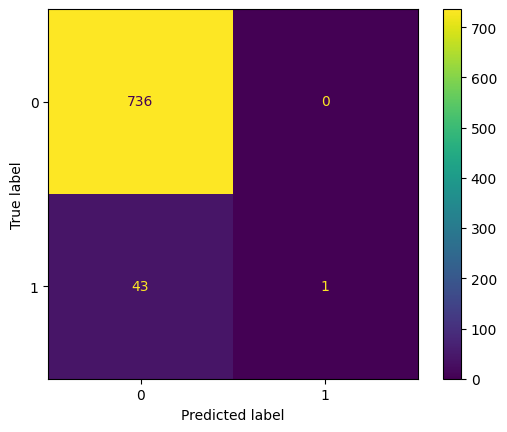

In [ ]:
# métricas de avaliação
acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
print(f"Acurácia: {acc_xgb:.4f}")
print(f"Recall: {rec_xgb:.4f}")
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
print(f"Precisão: {prec_xgb:.4f}")
print(f"F1 score: {f1_xgb:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

# exibir matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)


## Random Forest

## SVM

## Avaliação



2. **Métricas de Avaliação**: Além da acurácia, o foco deve ser em métricas específicas, como sensibilidade (ou recall), precisão e a pontuação F1. Essas métricas fornecem uma visão mais clara da performance do modelo em identificar casos positivos.

3. **Interpretação dos Resultados**: Docentes e profissionais de saúde devem estar envolvidos na interpretação dos resultados, para garantir que os insights derivados dos modelos sejam aplicáveis na prática e em conformidade com os protocolos clínicos.

Estas diretrizes abrangem a seleção de modelos de predição para hipertiroidismo, garantindo que pacientes em risco sejam adequ

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import ConfusionMatrixDisplay


## Comunicação dos resultado